In [13]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
now = datetime.now()

print(now.year, now.month, now.day, now.hour, now.minute, now.second, now.microsecond)
print(now)


2025 12 5 17 4 39 911727
2025-12-05 17:04:39.911727


In [3]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)

print("delta.seconds")
print(delta.seconds)   # 56700

print("\ndelta.days")
print(delta.days)      # 926

print("\ntype(delta)")
print(type(delta))     # datetime.timedelta


delta.seconds
56700

delta.days
926

type(delta)
<class 'datetime.timedelta'>


In [5]:
value_str = "2011-01-03"
value_datetime = datetime.strptime(value_str, "%Y-%m-%d")
print(value_datetime)     


2011-01-03 00:00:00


In [6]:
datestrs = ["7/6/2011", "8/6/2011"]
dates = [datetime.strptime(x, "%m/%d/%Y") for x in datestrs]
print(dates)
# [datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]


[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]


In [8]:
# Task 1
# Convert the string to a datetime object
date_time_obj = datetime.strptime('2023-10-26 14:45:00', '%Y-%m-%d %H:%M:%S')

# Format a: 'Month DD, YYYY - HH:MM AM/PM'
formatted_date_time_1 = date_time_obj.strftime('%B %d, %Y - %I:%M %p')

# Format b: 'HH:MM AM/PM'
formatted_date_time_2 = date_time_obj.strftime('%I:%M %p')

print(formatted_date_time_1)   # October 26, 2023 - 02:45 PM
print(formatted_date_time_2)   # 02:45 PM


October 26, 2023 - 02:45 PM
02:45 PM


In [10]:
datestrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00"]


# Basic conversion
print(pd.to_datetime(datestrs))
# DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

# It can handle missing values as ‘NaT’ (not a time)
# Conversion with a None value
print(pd.to_datetime(datestrs + [None]))
# DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

# Check for missing values
print(pd.isna(pd.to_datetime(datestrs + [None])))
# array([False, False, True])


DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)
[False False  True]


In [11]:
data = pd.read_csv('dow_jones_index.csv')
data.head()


,quarter,stock,date,open,high,low,close,volume,percent_change_price,percent_change_volume_over_last_wk,previous_weeks_volume,next_weeks_open,next_weeks_close,percent_change_next_weeks_price,days_to_next_dividend,percent_return_next_dividend
0,1,AA,1/7/2011,$15.82,$16.72,$15.78,$16.42,239655616,3.79267,NaN,NaN,$16.71,$15.97,-4.428490,26,0.182704
1,1,AA,1/14/2011,$16.71,$16.71,$15.64,$15.97,242963398,-4.42849,1.380223,239655616.0,$16.19,$15.79,-2.470660,19,0.187852
2,1,AA,1/21/2011,$16.19,$16.38,$15.60,$15.79,138428495,-2.47066,-43.024959,242963398.0,$15.87,$16.13,1.638310,12,0.189994
3,1,AA,1/28/2011,$15.87,$16.63,$15.82,$16.13,151379173,1.63831,9.355500,138428495.0,$16.18,$17.14,5.933250,5,0.185989
4,1,AA,2/4/2011,$16.18,$17.39,$16.18,$17.14,154387761,5.93325,1.987452,151379173.0,$17.33,$17.37,0.230814,97,0.175029


In [ ]:
data = pd.read_csv('dow_jones_index.csv')

data_ibm = data[data["stock"] == "IBM"].copy()
data_ibm['date'] = pd.to_datetime(data_ibm['date'])
# set index as date column
data_ibm.set_index('date', inplace=True)

# use min amd max to get first and last
print(f"First date: {data_ibm.index.min()}")
print(f"Last date: {data_ibm.index.max()}")


First date: 2011-01-07 00:00:00
Last date: 2011-06-24 00:00:00


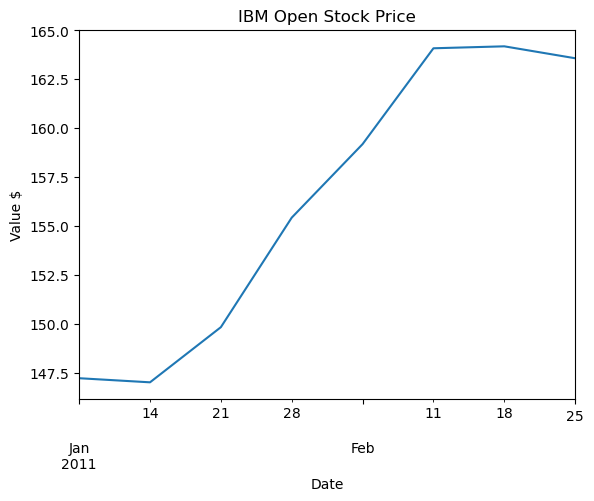

In [ ]:
# replace dollar signs by nothing#
# now have float column we cn ue to compare thignss
data_ibm['open'] = data_ibm['open'].str.replace('$', '').astype(float)

# use a slice
subset = data_ibm['2011-01-07':'2011-02-28']
subset['open'].plot(
    title='IBM Open Stock Price',
    ylabel='Value $',
    xlabel='Date'
)

plt.show()


In [18]:
# Task 4
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
# ME  = month edn frequency
monthly_max_stocks = data_ibm['high'].resample('ME').max()
print(monthly_max_stocks)
print(data_ibm['high'].dtype)

# Convert the 'high' column to numeric before resampling:'
quarterly_avg_stocks = monthly_max_stocks.resample('QE').mean()
print(quarterly_avg_stocks)


date
2011-01-31    $164.35
2011-02-28    $166.25
2011-03-31    $167.72
2011-04-30    $173.00
2011-05-31    $173.54
2011-06-30    $169.89
Freq: ME, Name: high, dtype: object
object


TypeError: agg function failed [how->mean,dtype->object]